## Setup: Imports + Helper Function


In [118]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def load_image(path, grayscale=False):
    flag = cv2.IMREAD_GRAYSCALE if grayscale else cv2.IMREAD_COLOR
    img = cv2.imread(path, flag)
    if img is None:
        raise FileNotFoundError(
            f"Could not load '{path}'. Download the image for this task "
            f"and place it in the same 'images/' folder as this notebook."
        )
    return img

def show(img1, img2, titles=("Original", "Transformed"), figsize=(12, 6)):
    imgs = [img1, img2]
    fig, axes = plt.subplots(1, len(imgs), figsize=figsize)
    for ax, im, t in zip(axes, imgs, titles):
        if im is None:
            ax.axis("off")
            continue
        if im.ndim == 3:
            im_show = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
            ax.imshow(im_show)
        else:
            ax.imshow(im, cmap="gray")
        ax.set_title(t)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

## Task 1: The Tiny Fingerprint (Linear - Scale)

Build a 2x2 scaling matrix by hand, enlarge by 300% on both axes, and keep the result centered on the original frame.


original shape: (750, 1000, 3)
scaled shape:   (2250, 3000, 3)


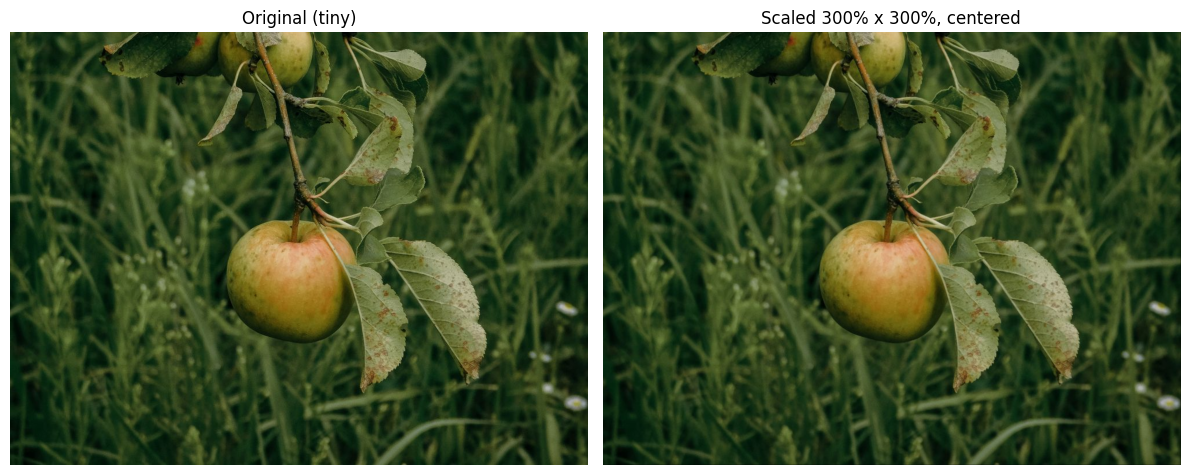

In [46]:
img1 = load_image('images/01.jpg')
h, w = img1.shape[:2]

sx, sy = 3.0, 3.0

S = np.array([[sx, 0],
              [0, sy]], dtype=np.float32)

new_w, new_h = int(round(w * sx)), int(round(h * sy))

cx, cy = w / 2, h / 2
new_cx, new_cy = new_w / 2, new_h / 2
tx = new_cx - S[0, 0] * cx
ty = new_cy - S[1, 1] * cy

M = np.array([[S[0, 0], S[0, 1], tx],
              [S[1, 0], S[1, 1], ty]], dtype=np.float32)

scaled = cv2.warpAffine(img1, M, (new_w, new_h))

print("original shape:", img1.shape)
print("scaled shape:  ", scaled.shape)

show(img1, scaled, ("Original (tiny)", "Scaled 300% x 300%, centered"))

## Task 2: The Dizzy Satellite (Linear - Rotation)

Build a 2x2 rotation matrix from sine/cosine, spin the 45-degree photo back to true north, and manually compute the output canvas size so no corners are clipped.


original shape: (1485, 1485, 3)
rotated shape:  (2101, 2101, 3)


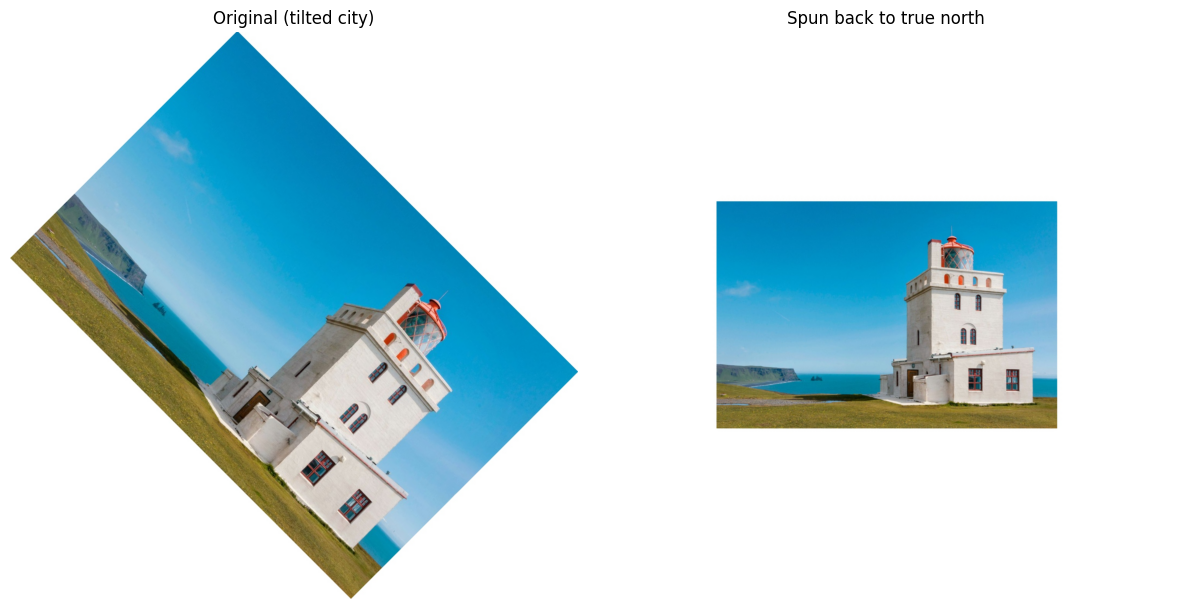

In [75]:
img2 = load_image("images/02.jpg")
h, w = img2.shape[:2]

theta = np.deg2rad(-45)

R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]], dtype=np.float32)

corners = np.array([[0, 0], [w, 0], [0, h], [w, h]], dtype=np.float32)
rotated_corners = corners @ R.T
min_xy = rotated_corners.min(axis=0)
max_xy = rotated_corners.max(axis=0)
new_w, new_h = np.ceil(max_xy - min_xy).astype(int)

tx, ty = -min_xy
M = np.array([[R[0, 0], R[0, 1], tx],
              [R[1, 0], R[1, 1], ty]], dtype=np.float32)

rotated = cv2.warpAffine(img2, M, (new_w, new_h), borderValue=(255, 255, 255))

print("original shape:", img2.shape)
print("rotated shape: ", rotated.shape)

show(img2, rotated, ("Original (tilted city)", "Spun back to true north"))

## Task 3: The Fast Train Barcode (Linear - Shear)

Build a 2x2 shear matrix that pushes pixels horizontally to undo the rightward slant, expanding the canvas so nothing is cut off.


original shape: (427, 811, 3)
sheared shape:  (427, 982, 3)


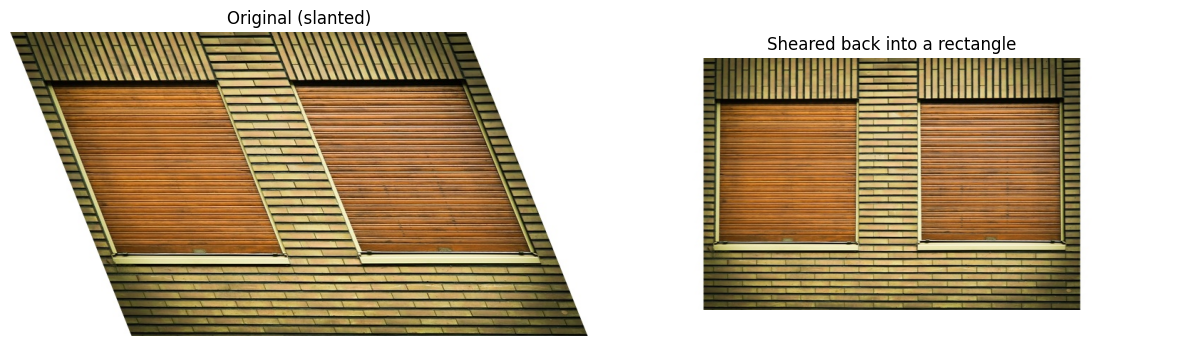

In [77]:
img3 = load_image("images/03.jpg")
h, w = img3.shape[:2]

shear_factor = -0.4

Sh = np.array([[1, shear_factor],
               [0, 1]], dtype=np.float32)

corners = np.array([[0, 0], [w, 0], [0, h], [w, h]], dtype=np.float32)
sheared_corners = corners @ Sh.T
min_xy = sheared_corners.min(axis=0)
max_xy = sheared_corners.max(axis=0)
new_w, new_h = np.ceil(max_xy - min_xy).astype(int)
tx, ty = -min_xy

M = np.array([[Sh[0, 0], Sh[0, 1], tx],
              [Sh[1, 0], Sh[1, 1], ty]], dtype=np.float32)

sheared = cv2.warpAffine(img3, M, (new_w, new_h), borderValue=(255, 255, 255))

print("original shape:", img3.shape)
print("sheared shape: ", sheared.shape)

show(img3, sheared, ("Original (slanted)", "Sheared back into a rectangle"))

## Task 4: The Hidden Treasure Map (Affine - Translation)

Upgrade to a 3x3 matrix to allow movement, and build a pure translation matrix that slides the map back into frame.


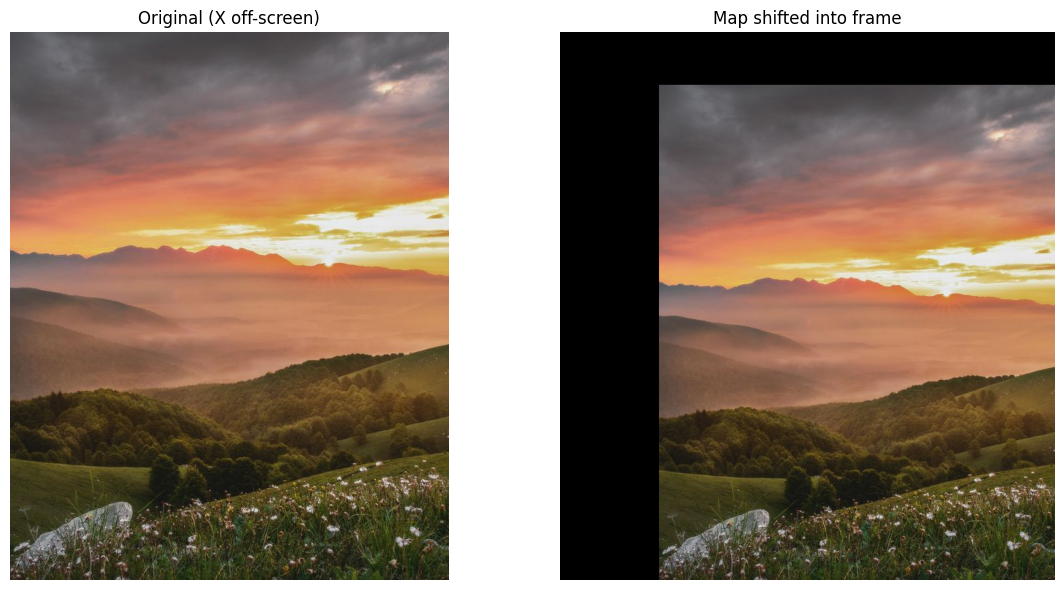

In [85]:
img4 = load_image("images/04.jpg")
h, w = img4.shape[:2]

tx, ty = 150, 80

T = np.array([[1, 0, tx],
              [0, 1, ty],
              [0, 0, 1]], dtype=np.float32)

translated = cv2.warpAffine(img4, T[:2, :], (w + tx, h + ty))
show(img4, translated, ("Original (X off-screen)", "Map shifted into frame"))

## Task 5: The Robot's Assembly Line (Rigid Transformation)

Combine a rotation matrix and a translation matrix into a single 3x3 rigid transformation, applied in one pass.


Rigid transformation matrix:
 [[ 0.9961947   0.08715574 35.        ]
 [-0.08715574  0.9961947  15.        ]
 [ 0.          0.          1.        ]]


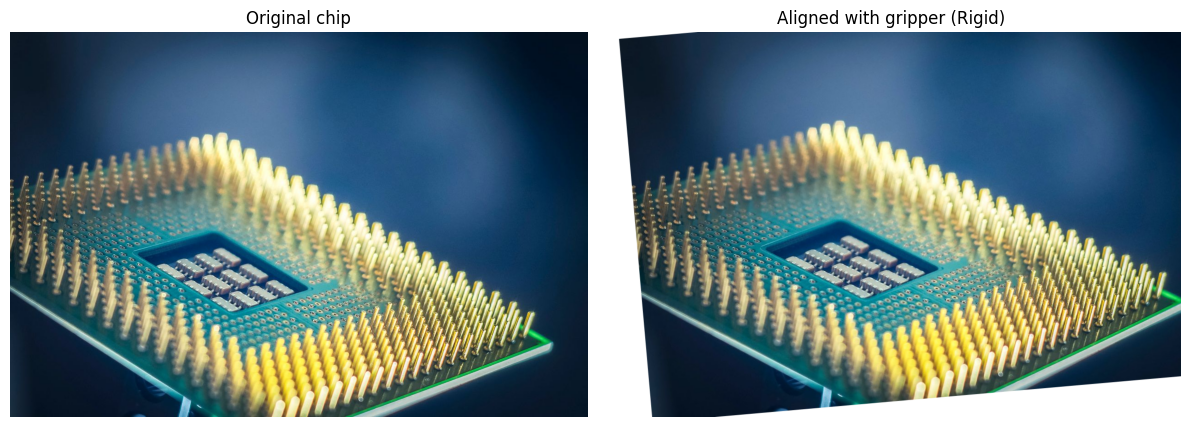

In [94]:
img5 = load_image("images/05.jpg")
h, w = img5.shape[:2]

theta = np.deg2rad(-5)
tx, ty = 35, 15

R3 = np.array([[np.cos(theta), -np.sin(theta), 0],
               [np.sin(theta),  np.cos(theta), 0],
               [0, 0, 1]], dtype=np.float32)

T3 = np.array([[1, 0, tx],
               [0, 1, ty],
               [0, 0, 1]], dtype=np.float32)

Rigid = T3 @ R3
print("Rigid transformation matrix:\n", Rigid)

rigid_result = cv2.warpAffine(img5, Rigid[:2, :], (w, h), borderValue=(255, 255, 255))
show(img5, rigid_result, ("Original chip", "Aligned with gripper (Rigid)"))

## Task 6: The Architect's Blueprint (Similarity Transformation)

Combine Scale, Rotation, and Translation into one 3x3 similarity matrix (angles preserved, size changed).


[[  1.2950531   -0.11330246  20.        ]
 [  0.11330246   1.2950531  -50.        ]
 [  0.           0.           1.        ]]


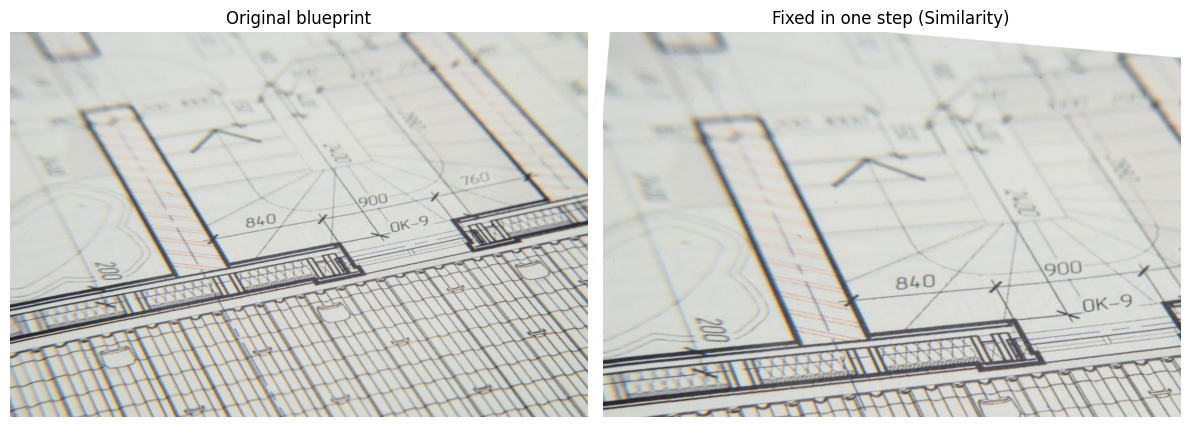

In [104]:
img6 = load_image("images/06.jpg")
h, w = img6.shape[:2]

s = 1.3
theta = np.deg2rad(5)
tx, ty = 20, -50

S3 = np.array([[s, 0, 0],
               [0, s, 0],
               [0, 0, 1]], dtype=np.float32)

R3 = np.array([[np.cos(theta), -np.sin(theta), 0],
               [np.sin(theta),  np.cos(theta), 0],
               [0, 0, 1]], dtype=np.float32)

T3 = np.array([[1, 0, tx],
               [0, 1, ty],
               [0, 0, 1]], dtype=np.float32)

Similarity = T3 @ R3 @ S3
print(Similarity)

sim_result = cv2.warpAffine(img6, Similarity[:2, :], (w, h), borderValue=(255, 255, 255))
show(img6, sim_result, ("Original blueprint", "Fixed in one step (Similarity)"))

## Task 7: The Glitched Image (General Affine Transformation)

Given 3 landmark points before/after, solve a system of linear equations for the 6 unknowns of a general affine matrix, then apply it.


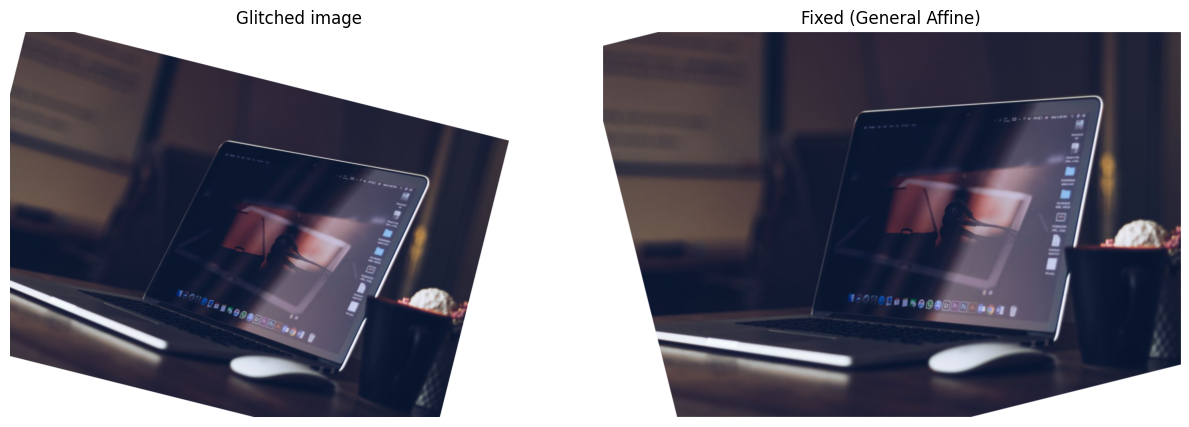

In [127]:
img7 = load_image("images/07.jpg")
h, w = img7.shape[:2]

# 1) Adding glitch so that I can remove them as task requires it
theta, scale, tx, ty = np.deg2rad(12), 0.85, 40, -25
TrueM = np.array([[scale*np.cos(theta), -np.sin(theta), tx],
                   [np.sin(theta),  scale*np.cos(theta), ty]], dtype=np.float32)
glitched = cv2.warpAffine(img7, TrueM, (w, h), borderValue=(255, 255, 255))

# 2) Removing glitch
src_pts = np.float32([[60, 60], [w - 70, 50], [50, h - 80]])
ones = np.ones((3, 1), dtype=np.float32)
glitched_pts = (TrueM @ np.hstack([src_pts, ones]).T).T

A, bvec = [], []
for (xp, yp), (x, y) in zip(glitched_pts, src_pts):
    A.append([xp, yp, 1, 0, 0, 0]); bvec.append(x)
    A.append([0, 0, 0, xp, yp, 1]); bvec.append(y)

a, b, c, d, e, f = np.linalg.solve(np.array(A, dtype=np.float64), np.array(bvec, dtype=np.float64))
AffineM = np.array([[a, b, c], [d, e, f]], dtype=np.float32)

fixed = cv2.warpAffine(glitched, AffineM, (w, h), borderValue=(255, 255, 255))
show(glitched, fixed, ("Glitched image", "Fixed (General Affine)"))

## Task 8: The Sidewalk Illusion (Projective - Perspective)

Pick the 4 corners that should mathematically form a perfect square, build a perspective matrix, and warp to a bird's-eye view.

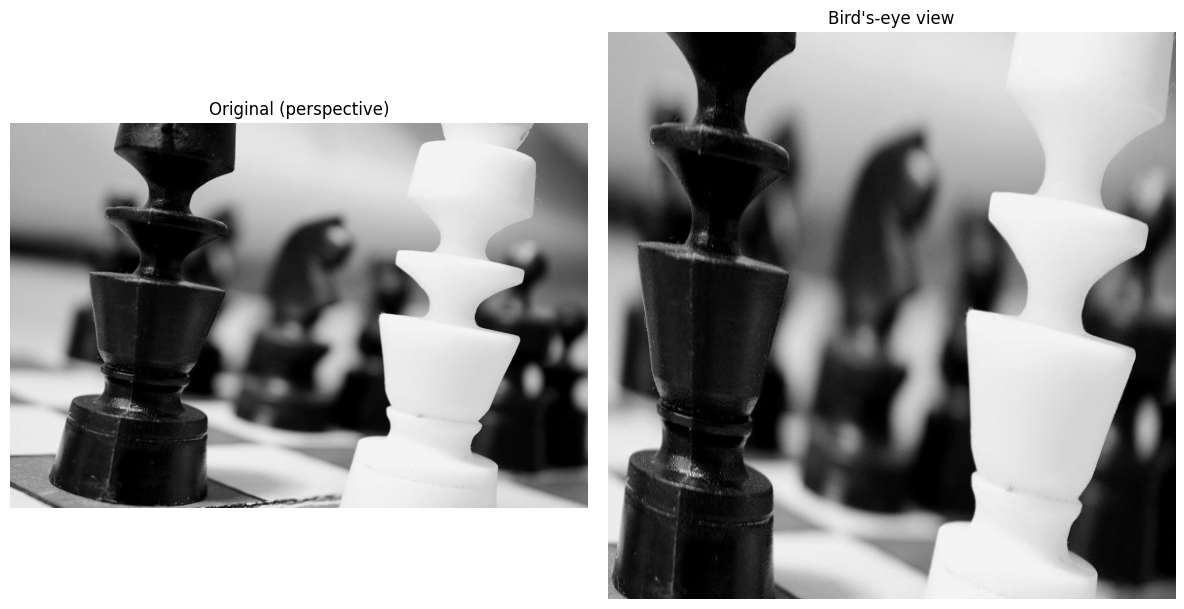

In [ ]:
img8 = load_image("images/08.jpg")
h, w = img8.shape[:2]

src_pts = np.float32([[110, 60], [w - 90, 90], [w - 40, h - 50], [60, h - 30]])

side = min(w, h) - 100
dst_pts = np.float32([[0, 0], [side, 0], [side, side], [0, side]])

Persp = cv2.getPerspectiveTransform(src_pts, dst_pts)
birdseye = cv2.warpPerspective(img8, Persp, (side, side))
show(img8, birdseye, ("Original (perspective)", "Bird's-eye view"))

## Task 9: The Stadium Panorama (Projective - Homography)

Find matching points in two overlapping photos, calculate the homography matrix, and stitch them into one panorama.

*(ORB automatically finds the 4 strongest matching points between the two photos; if you'd rather pick them by hand, use `plt.ginput(4)` on each image instead and skip the ORB block.)*

1310 good matches out of 3774 candidates
1274 inliers used for the final homography


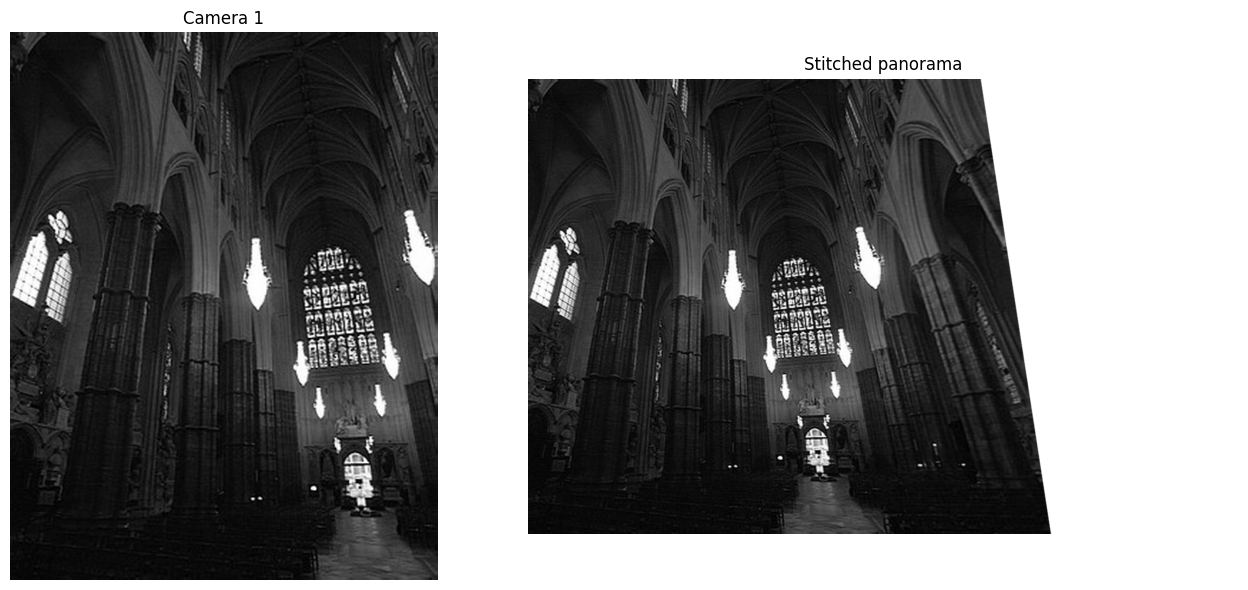

In [122]:
imgL = load_image("images/09a.png", True)
imgR = load_image("images/09b.png", True)

orb = cv2.ORB_create(4000)
kpL, desL = orb.detectAndCompute(imgL, None)
kpR, desR = orb.detectAndCompute(imgR, None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING)
raw_matches = bf.knnMatch(desL, desR, k=2)

good = [m for m, n in raw_matches if m.distance < 0.75 * n.distance]
print(f"{len(good)} good matches out of {len(raw_matches)} candidates")

ptsL = np.float32([kpL[m.queryIdx].pt for m in good])
ptsR = np.float32([kpR[m.trainIdx].pt for m in good])

H, mask = cv2.findHomography(ptsR, ptsL, cv2.RANSAC, 5.0)
print(f"{int(mask.sum())} inliers used for the final homography")

hL, wL = imgL.shape[:2]
hR, wR = imgR.shape[:2]
canvas_w = wL + wR

pano = cv2.warpPerspective(imgR, H, (canvas_w, max(hL, hR)), borderValue=(255, 255, 255))
pano[0:hL, 0:wL] = imgL

show(imgL, pano, ("Camera 1", "Stitched panorama"), figsize=(14, 6))

## Task 10: The Master Forger (Full Hierarchy Challenge)

Traverse the entire hierarchy: **Scale** the painting down, **Rigid**-move it near the frame, then **Projective**-warp its corners into the angled frame, all combined into one 3x3 matrix.

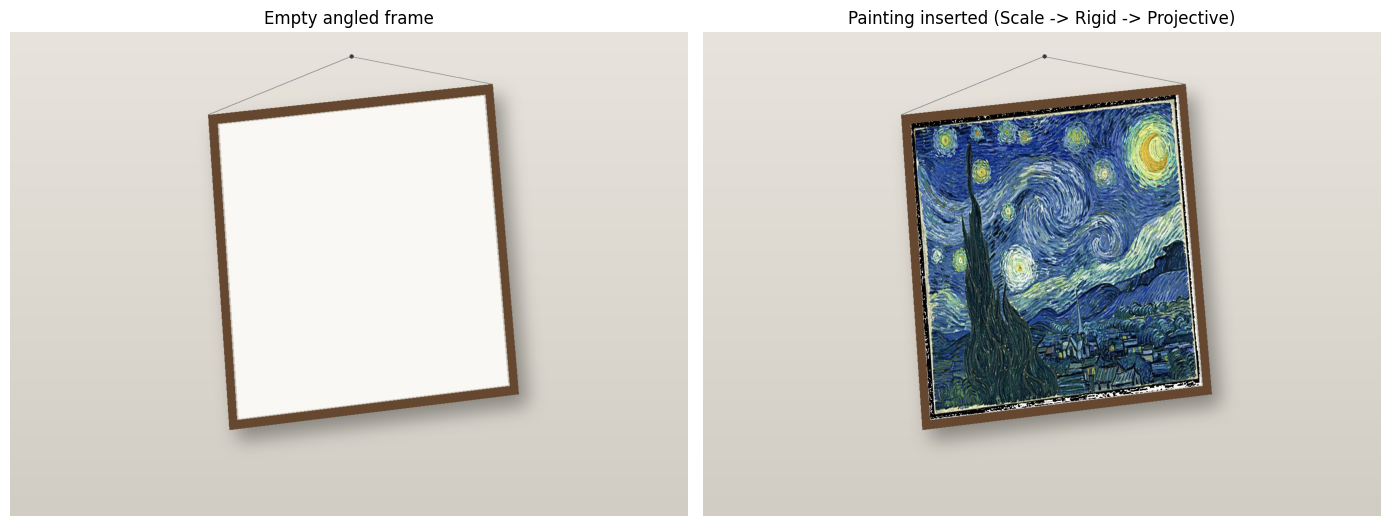

In [132]:
painting = load_image("images/10a.jpg")
wall = load_image("images/10b.jpg")

ph, pw = painting.shape[:2]
wh, ww = wall.shape[:2]

scale = 0.5
S3 = np.array([[scale, 0, 0],
               [0, scale, 0],
               [0, 0, 1]], dtype=np.float32)

theta = np.deg2rad(4)
tx, ty = ww * 0.15, wh * 0.15
R3 = np.array([[np.cos(theta), -np.sin(theta), 0],
               [np.sin(theta),  np.cos(theta), 0],
               [0, 0, 1]], dtype=np.float32)
T3 = np.array([[1, 0, tx],
               [0, 1, ty],
               [0, 0, 1]], dtype=np.float32)
Rigid = T3 @ R3

HierarchySoFar = Rigid @ S3

corners = np.float32([[0, 0], [pw, 0], [pw, ph], [0, ph]])
homog = np.hstack([corners, np.ones((4, 1), dtype=np.float32)])
moved = (HierarchySoFar @ homog.T).T
moved = (moved[:, :2] / moved[:, [2]]).astype(np.float32)

frame_corners = np.float32([
    [430, 190],
    [980, 130],
    [1030, 730],
    [470, 800],
])

Projective = cv2.getPerspectiveTransform(moved, frame_corners)
FullMatrix = Projective @ HierarchySoFar

warped_painting = cv2.warpPerspective(painting, FullMatrix, (ww, wh))

mask = cv2.cvtColor(warped_painting, cv2.COLOR_BGR2GRAY) > 0
result = wall.copy()
result[mask] = warped_painting[mask]

show(wall, result, ("Empty angled frame", "Painting inserted (Scale -> Rigid -> Projective)"), figsize=(14, 7))